# `v70_fig1b_p38`

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

from common import EVALUATE_ALL_CSVS

model = "EGFR_MAPK__logobs"
data = "dream_cytof"
filename = "evaluate_all_figure1b"

df = pd.read_csv(EVALUATE_ALL_CSVS.format(model=model, data=data, filename=filename), index_col=0)

In [2]:
val_df = df[(df.dataset == "val") & (df.ref == "DMM")]
val_df.features.fillna("None", inplace=True)

In [3]:
val_df.groupby(["context", "features", "multiheaded", "n_hidden", "depth", "dropout_rate", "l1reg_inflater_output", "l2reg_inflater_output", "recon_loss"]).rmse.mean()

context          features           multiheaded  n_hidden  depth  dropout_rate  l1reg_inflater_output  l2reg_inflater_output  recon_loss
cytof_init       RFE_15_permute     False        2.0       0.0    0.0           0.1000                 0.0                    0.0001        0.563812
                                                                  0.1           0.1000                 0.0                    0.0001        0.597726
                                                                  0.2           0.0000                 0.0                    0.0001        0.614198
                                                                                0.0001                 0.0                    0.0001        0.610579
                                                                                0.0010                 0.0                    0.0001        0.596449
                                                                                                                      

# n_hidden (fixed depth=0)

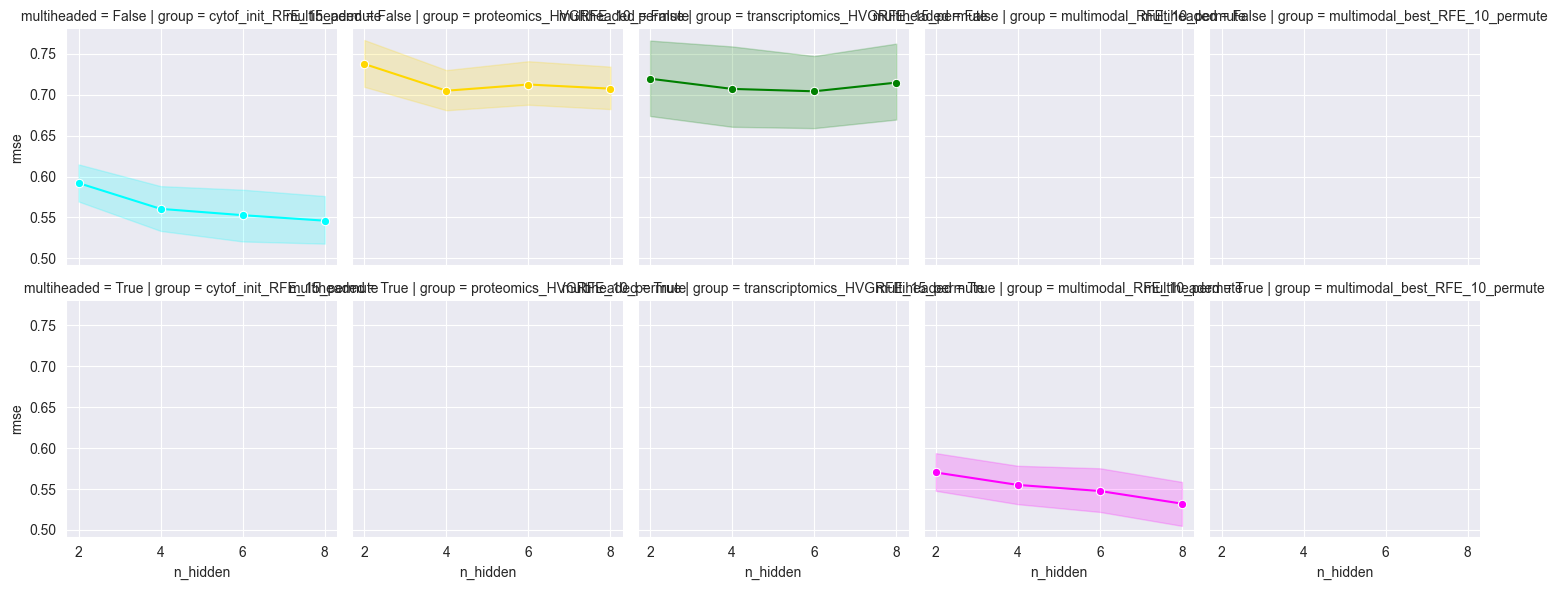

In [4]:
val_df["group"] = val_df["context"] + "_" + val_df["features"]

palette = {
    "cytof_init_RFE_15_permute": "cyan",
    "proteomics_HVGRFE_10_permute": "gold",
    "transcriptomics_HVGRFE_15_permute": "green",
    "multimodal_RFE_10_permute": "magenta",
    "multimodal_best_RFE_10_permute": "purple"
}

g = sns.FacetGrid(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys()
)

g.map_dataframe(
    sns.lineplot,
    x="n_hidden",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [5]:
from scipy import stats

def kruskal_wallis_groups(df, target_metric, group_metric, context_metric="context"):
    for context in df[context_metric].unique():
        context_data = df[df[context_metric] == context]
        groups = [group[target_metric].values for _, group in context_data.groupby(group_metric)]
        stat, p_value = stats.kruskal(*groups)
        print(f"Context/Group: {context} - Kruskal-Wallis H-test: H-statistic={stat:.2f}, p-value={p_value:.4f}, significant? {p_value < 0.05}")

In [6]:
kruskal_wallis_groups(
    val_df[(val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "n_hidden",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=3.21, p-value=0.3602, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=6.33, p-value=0.0967, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.42, p-value=0.4898, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.87, p-value=0.8319, significant? False


## No significant improvements, but there is a downward trend in most contexts (but transcriptomics)

# `depth` (fixed n_hidden = 2)

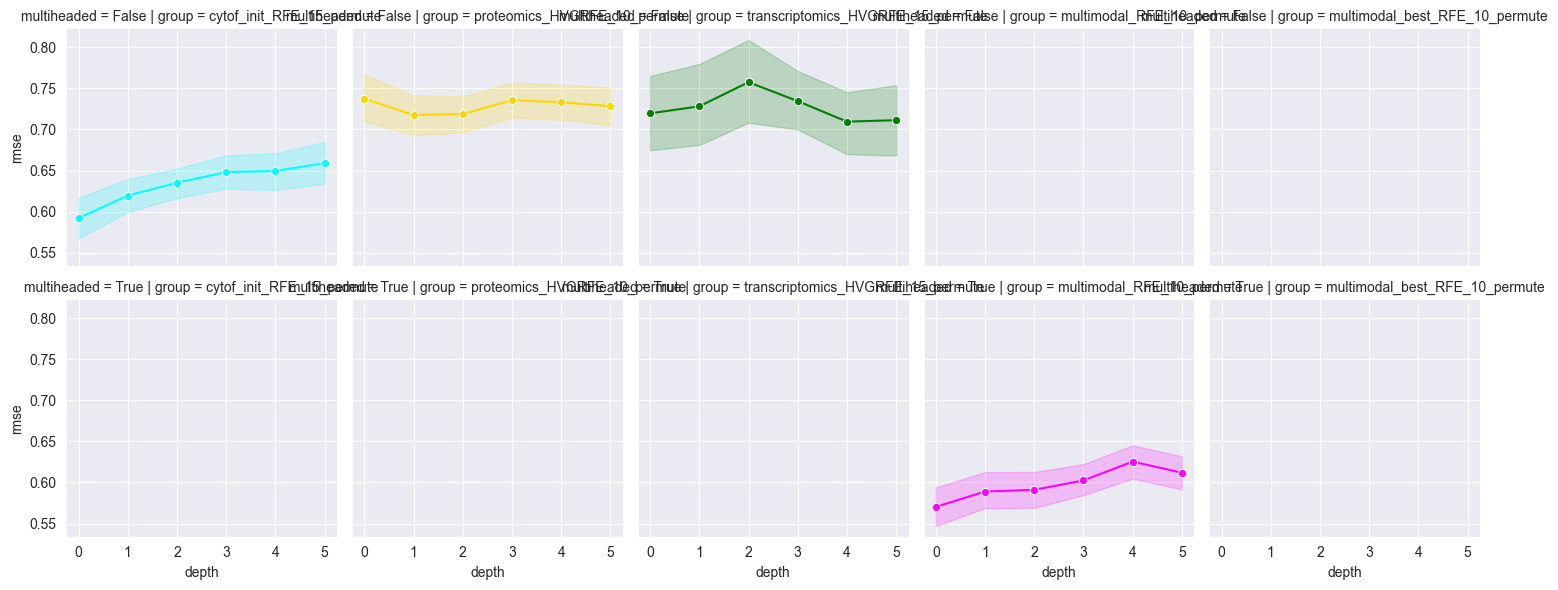

In [7]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="depth",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [8]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.l2reg_inflater_output == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "depth",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=15.62, p-value=0.0080, significant? True
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=17.88, p-value=0.0031, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=2.05, p-value=0.8421, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=1.34, p-value=0.9310, significant? False


## With re-centred parameters, now `depth` only hurts (apart from up-down trend in `transcriptomics`)

# `l1reg_inflater_output` (fixed `n_hidden`, `depth` and `l2reg_inflater_output`)

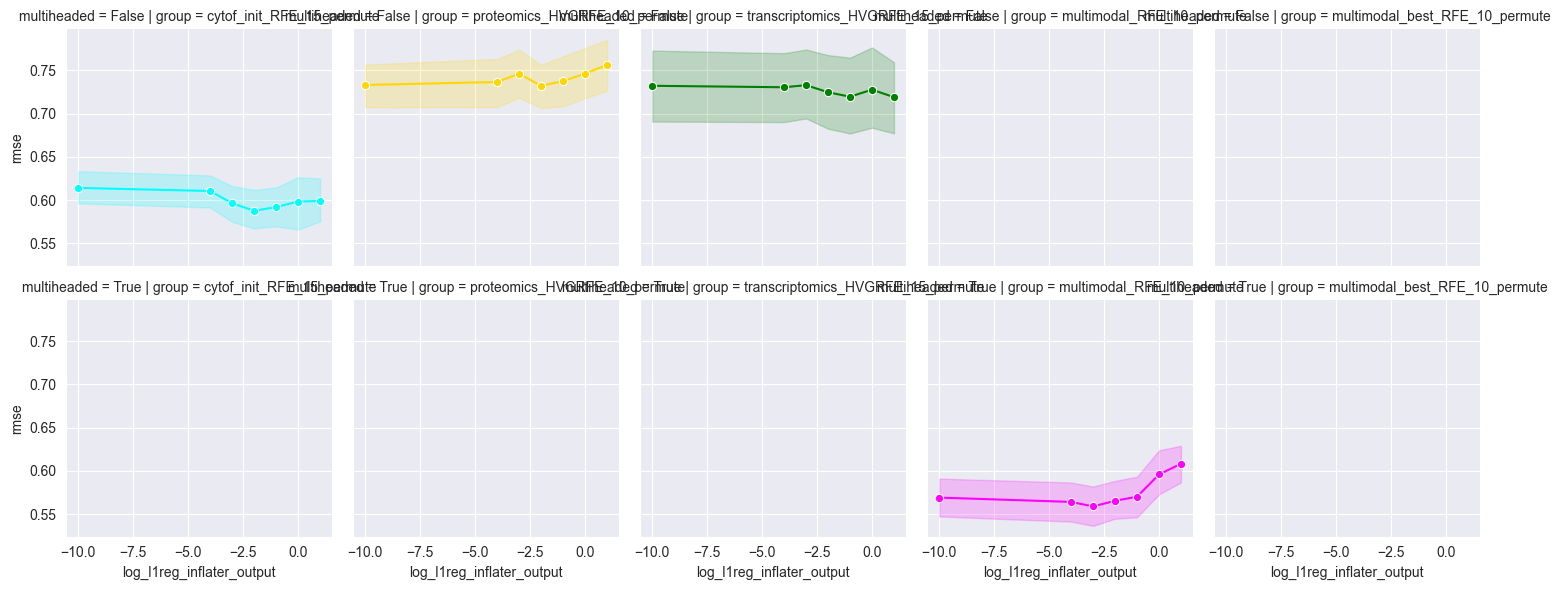

In [9]:
import numpy as np

val_df["log_l1reg_inflater_output"] = np.where(
    val_df["l1reg_inflater_output"] != 0,
    np.log10(val_df["l1reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l1reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [10]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l1reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=15.22, p-value=0.0186, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=1.87, p-value=0.9312, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.23, p-value=0.9998, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.72, p-value=0.5801, significant? False


## Trend dramatically changed with shift in `dropout_rate` -> now the sweet spot is the previous 1e-2 value, and anything above hurts (apart from transcriptomics which seems fine with 1e-1)

# `l2reg_inflater_output` (fixed `n_hidden`, `depth` and `l1reg_inflater_output`)

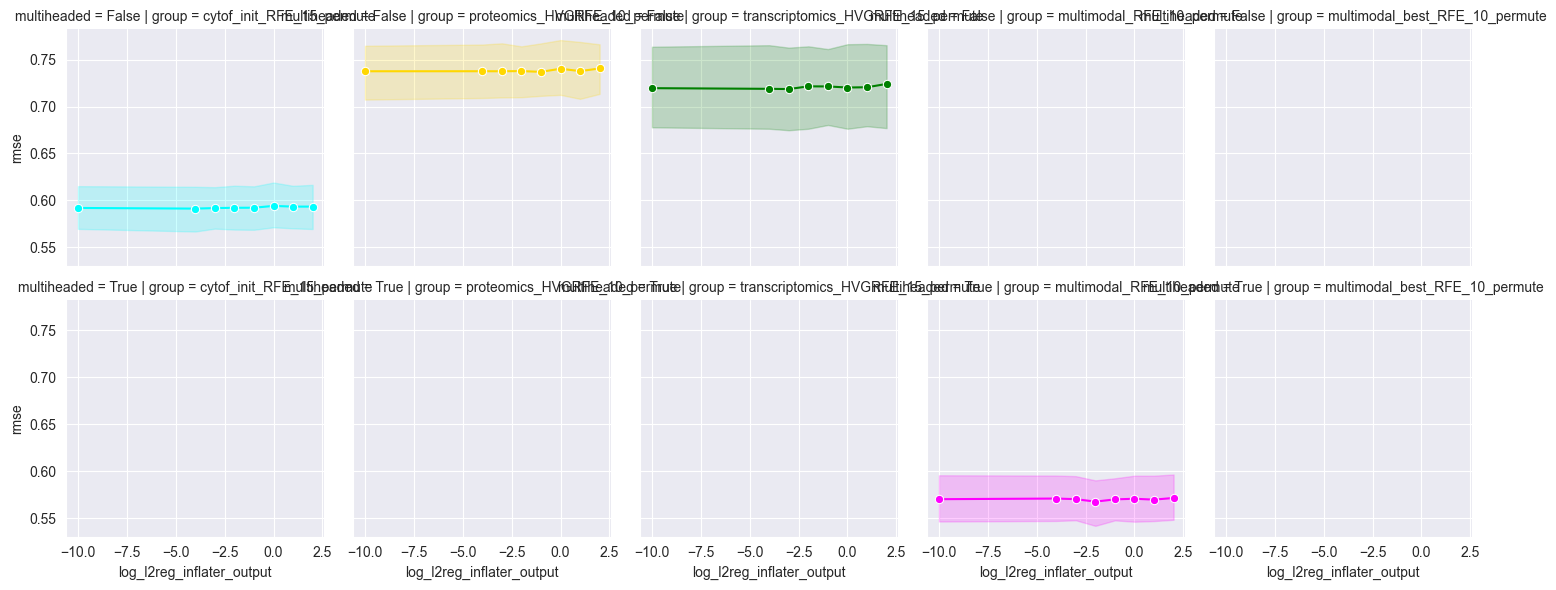

In [11]:
import numpy as np

val_df["log_l2reg_inflater_output"] = np.where(
    val_df["l2reg_inflater_output"] != 0,
    np.log10(val_df["l2reg_inflater_output"]),
    -10
)
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_l2reg_inflater_output",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [12]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.dropout_rate == 0.2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "log_l2reg_inflater_output",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.10, p-value=1.0000, significant? False
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=0.11, p-value=1.0000, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.10, p-value=1.0000, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=0.06, p-value=1.0000, significant? False


## As usual, unhelpful..

# Dropout Rate (`dropout_rate`)

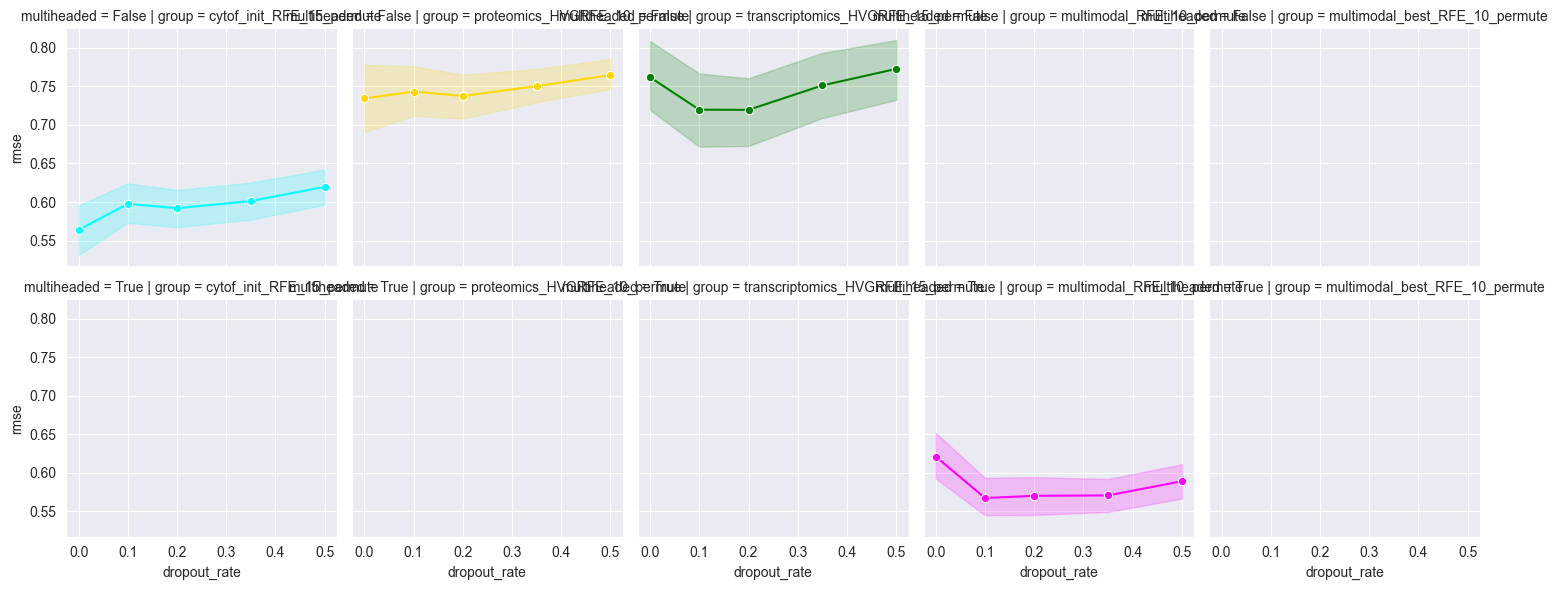

In [13]:
g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="dropout_rate",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

In [14]:
kruskal_wallis_groups(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.l2reg_inflater_output == 0) & (val_df.recon_loss == 1e-4)],
    "rmse",
    "dropout_rate",
    "group"
)

Context/Group: multimodal_RFE_10_permute - Kruskal-Wallis H-test: H-statistic=12.49, p-value=0.0141, significant? True
Context/Group: proteomics_HVGRFE_10_permute - Kruskal-Wallis H-test: H-statistic=7.99, p-value=0.0920, significant? False
Context/Group: cytof_init_RFE_15_permute - Kruskal-Wallis H-test: H-statistic=5.99, p-value=0.2000, significant? False
Context/Group: transcriptomics_HVGRFE_15_permute - Kruskal-Wallis H-test: H-statistic=4.30, p-value=0.3664, significant? False


## Seems like the double shift in `l1reg_inflater_output` and `dropout_rate` really screwed us over...now not beneficial for `cytof` or `proteomics, while `transcriptomics` and `multimodal` still cope with 0.2

# Reconstruction loss (`recon_loss`)

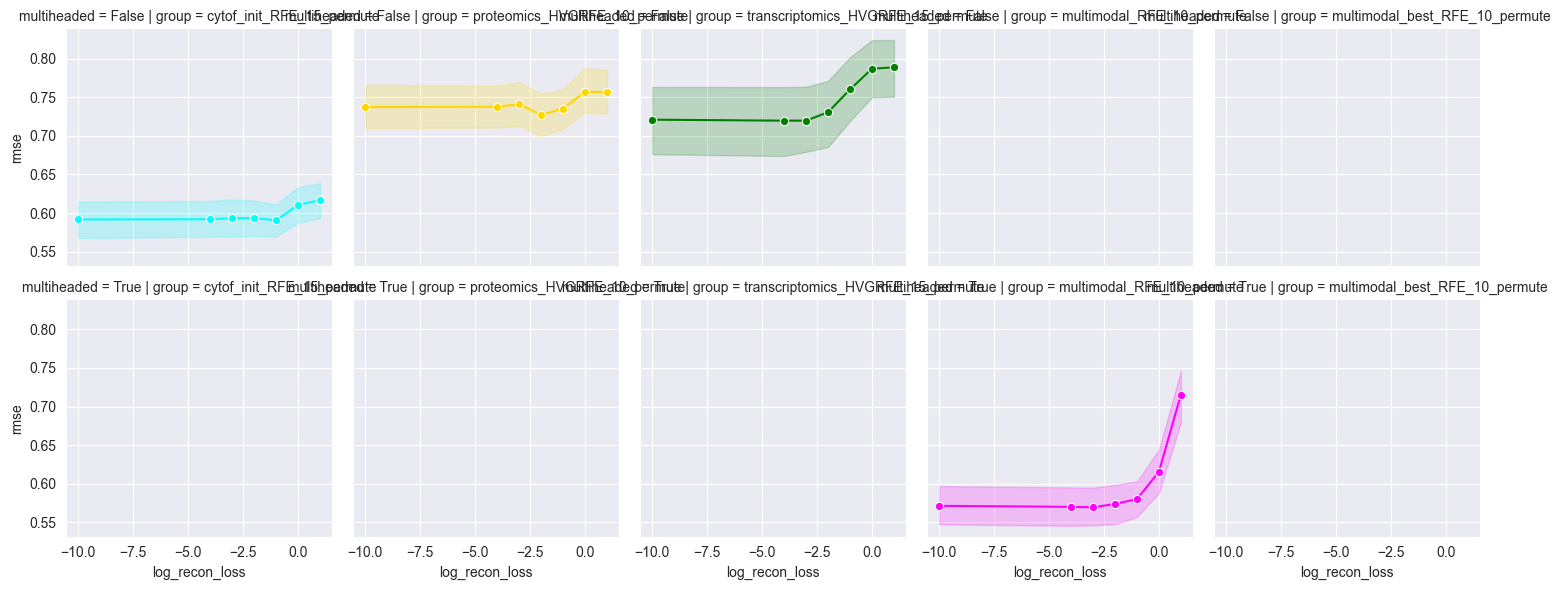

In [15]:
val_df["log_recon_loss"] = np.where(
    val_df["recon_loss"] != 0,
    np.log10(val_df["recon_loss"]),
    -10
)

g = sns.FacetGrid(
    val_df[(val_df.n_hidden == 2) & (val_df.depth == 0) & (val_df.dropout_rate == 0.2) & (val_df.l1reg_inflater_output == 1e-1) & (val_df.l2reg_inflater_output == 0)],
    row="multiheaded",
    col="group",
    col_order=palette.keys(),
)

g.map_dataframe(
    sns.lineplot,
    x="log_recon_loss",
    y="rmse",
    marker='o',
    hue="group",
    palette=palette
)

## Really dramatic change - now this only hurts with a super-tiny window of marginally helping in some context - clearly we need to tune `l1reg_inflater_output` and `dropout_rate` in a better way?!